# RépétIA — Banc d'évaluation des modèles, avant tout entraînement

**Phase 1 du plan d'entraînement** (`recherche/PLAN_ENTRAINEMENT.md`)

---

## Pourquoi ce notebook existe

RépétIA veut son propre modèle de langue. Une première tentative, en
septembre, a annoncé un modèle entraîné et un score de 96,5/100 : aucun
entraînement n'avait eu lieu et les métriques étaient codées en dur (voir
`evolu.md`, entrée du 2026-09-03).

Ce notebook pose donc la règle avant le premier entraînement : **on mesure
d'abord, sur un jeu de test figé, ce que valent les modèles candidats tels
quels**, ainsi que la référence (Gemini) et le plancher (l'application sans
LLM). L'entraînement de la phase 3 ne sera jugé qu'à l'aune de ces chiffres.

## Protocole

**Jeu de test v1** — `recherche/donnees/banc/jeu_de_test.jsonl`, construit par
`recherche/src/exporter_banc.js` à graine fixe (reproductible octet pour
octet), avec les prompts **exacts** de production exportés de
`backend/src/services/llm.service.ts`. Il couvre le catalogue actuel
(6ème → Terminale) ; les vagues suivantes du plan (lycée complet, primaire,
technique, supérieur) y ajouteront leurs items sans toucher à ceux-ci.

| Tâche | Items | Ce qu'on demande | Ce qu'on vérifie |
|---|---|---|---|
| `generation` | 300 | un exercice sur un thème du catalogue | JSON conforme, longueurs, défauts d'écriture |
| `resolution` | 150 | résoudre un énoncé issu d'un **générateur** paramétré | la solution, **recalculée** par le générateur |
| `correction` | 300 | juger une réponse d'élève **fabriquée** (150 justes, 150 fausses) | le verdict, **connu par construction** |

**Métrique principale : « utilisable »** — la réponse pourrait être servie à un
élève : JSON conforme au schéma de production, sans LaTeX, sans titre
Markdown, sans français désaccentué, sans anglais hors des cours de langue,
et, selon la tâche, juste (résolution) ou au bon verdict (correction).

**Deux lignes qui ne sont pas des modèles** servent de repères :

- `plancher:application-sans-llm` — ce que l'application sert aujourd'hui
  quand aucun modèle ne répond (exercice de secours, correction de repli qui
  répond toujours « faux ») ;
- `controle:reference` — la réponse attendue elle-même. Elle **doit** obtenir
  100 % : c'est l'autotest de la notation. Si elle ne l'obtient pas, c'est le
  scoreur qui est faux, et aucun autre chiffre de ce notebook ne vaut rien.

**Limite assumée : la référence Gemini ne voit qu'un sous-échantillon** (30
items par tâche, réparti sur les niveaux), le palier gratuit limitant les
appels. Les comparaisons avec Gemini se font donc **sur les mêmes items**
(section 3), jamais en opposant un score sur 30 à un score sur 300.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import pandas as pd
import matplotlib.pyplot as plt
import analyse, banc
from analyse import COULEURS

analyse.appliquer_style()
pd.set_option("display.width", 160)

jeu = banc.charger_jeu()
reponses = banc.reponses_par_modele()
r = banc.rapport()
print(f"Jeu de test : {len(jeu)} items — " +
      ", ".join(f"{t} {sum(i['tache'] == t for i in jeu)}" for t in banc.TACHES))
for modele, rep in reponses.items():
    print(f"  {modele:<45} {len(rep):>4} réponses")

Jeu de test : 750 items — generation 300, resolution 150, correction 300
  controle:reference                             450 réponses
  gemini:gemini-flash-lite-latest                 30 réponses
  plancher:application-sans-llm                  750 réponses


---
## 1. Autotest de la notation

Avant de lire le moindre score : la réponse de référence doit obtenir 100 %
sur la résolution et la correction. La cellule échoue sinon.

In [2]:
controle = r["modeles"]["controle:reference"]["taches"]
for tache in ("resolution", "correction"):
    taux = controle[tache]["utilisable"]["taux"]
    print(f"{tache:<11} utilisable = {taux:.3f}  (n = {controle[tache]['n']})")
    assert taux == 1.0, f"le scoreur rejette la réponse de référence en {tache}"
print("Autotest réussi : le scoreur reconnaît les réponses attendues.")

resolution  utilisable = 1.000  (n = 150)
correction  utilisable = 1.000  (n = 300)
Autotest réussi : le scoreur reconnaît les réponses attendues.


---
## 2. Tableau général

Pour chaque modèle et chaque tâche : effectif, taux de JSON conforme, taux
« utilisable » avec son intervalle de confiance à 95 % (Wilson), et la
métrique de justesse propre à la tâche. Les effectifs diffèrent d'un modèle
à l'autre (Gemini : sous-échantillon) — la section 3 compare à items égaux.

In [3]:
def tableau(rapport):
    lignes = []
    for modele, m in rapport["modeles"].items():
        if modele.startswith("controle:"):
            continue
        for tache, b in m["taches"].items():
            u = b["utilisable"]
            ligne = {
                "modèle": modele, "tâche": tache, "n": b["n"],
                "conforme": b["conforme"]["taux"],
                "utilisable": u["taux"],
                "IC95": f"[{u['ic95'][0]:.2f} ; {u['ic95'][1]:.2f}]" if u["n"] else "—",
            }
            if tache == "resolution":
                ligne["juste"] = b["juste"]["taux"]
            if tache == "correction":
                ligne["verdict juste"] = b["verdict_juste"]["taux"]
                ligne["rappel « faux »"] = b["rappel_faux"]["taux"]
            ligne["latence méd. (s)"] = m["latence_mediane_s"]
            lignes.append(ligne)
    return pd.DataFrame(lignes).set_index(["tâche", "modèle"]).sort_index()

tableau(r)

n  conforme  utilisable           IC95  latence méd. (s)  juste  verdict juste  rappel « faux »
tâche      modèle                                                                                                                            
correction plancher:application-sans-llm    300    1.0000      0.5000  [0.44 ; 0.56]             0.000    NaN            0.5              1.0
generation gemini:gemini-flash-lite-latest   30    0.9667      0.8667  [0.70 ; 0.95]             1.708    NaN            NaN              NaN
           plancher:application-sans-llm    300    1.0000      0.9933  [0.98 ; 1.00]             0.000    NaN            NaN              NaN
resolution plancher:application-sans-llm    150    0.0000      0.0000  [0.00 ; 0.03]             0.000    NaN            NaN              NaN

---
## 3. Comparaison à items égaux avec la référence Gemini

Tous les modèles sont notés **sur les seuls items que Gemini a reçus**. C'est
la seule comparaison honnête avec la référence : un sous-échantillon de 30
items par tâche donne des intervalles larges, que la figure montre.

30 items vus par gemini:gemini-flash-lite-latest


n  conforme  utilisable           IC95  latence méd. (s)
tâche      modèle                                                                                    
generation gemini:gemini-flash-lite-latest  30    0.9667      0.8667  [0.70 ; 0.95]             1.708
           plancher:application-sans-llm    30    1.0000      1.0000  [0.89 ; 1.00]             0.000

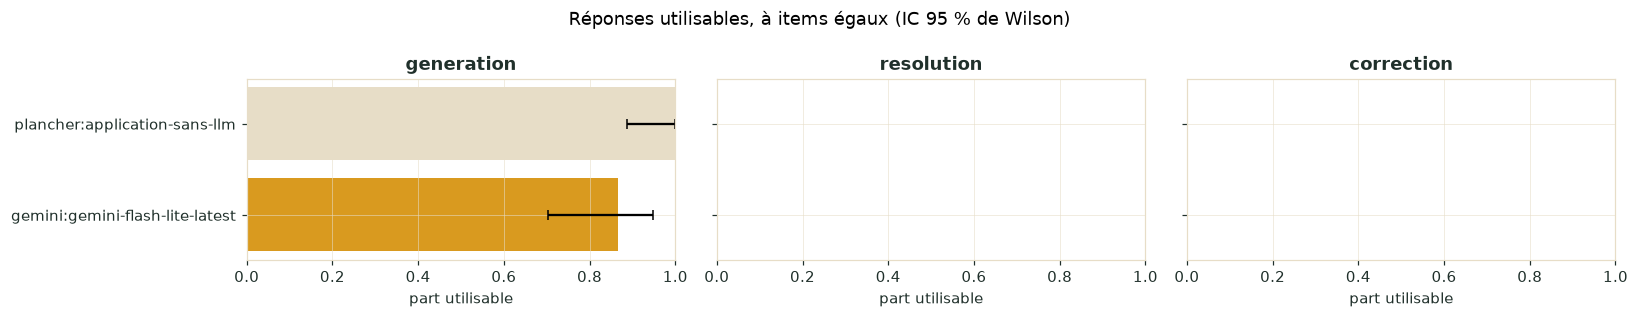

In [4]:
geminis = [m for m in reponses if m.startswith("gemini:")]
if not geminis:
    print("Aucune réponse Gemini collectée pour l'instant.")
else:
    ids_communs = set.intersection(*(set(reponses[m]) for m in geminis))
    r_apparie = banc.rapport(restreindre_a=ids_communs)
    print(f"{len(ids_communs)} items vus par {', '.join(geminis)}")
    t = tableau(r_apparie)
    display(t)

    modeles = [m for m in r_apparie["modeles"] if not m.startswith("controle:")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 0.55 * len(modeles) + 1.8), sharey=True)
    for ax, tache in zip(axes, banc.TACHES):
        valeurs, bas, hauts = [], [], []
        for m in modeles:
            b = r_apparie["modeles"][m]["taches"].get(tache)
            u = b["utilisable"] if b else {"taux": 0, "ic95": (0, 0)}
            v = u["taux"] or 0
            valeurs.append(v)
            bas.append(max(0, v - (u["ic95"][0] if u["ic95"][0] == u["ic95"][0] else v)))
            hauts.append(max(0, (u["ic95"][1] if u["ic95"][1] == u["ic95"][1] else v) - v))
        couleurs = [COULEURS["dore"] if m.startswith("gemini") else
                    COULEURS["lignes"] if m.startswith("plancher") else COULEURS["vert"] for m in modeles]
        ax.barh(modeles, valeurs, xerr=[bas, hauts], color=couleurs, capsize=3)
        ax.set_xlim(0, 1)
        ax.set_title(tache)
        ax.set_xlabel("part utilisable")
    fig.suptitle("Réponses utilisables, à items égaux (IC 95 % de Wilson)")
    fig.tight_layout()
    fig.savefig(pathlib.Path.cwd().parent / "figures/05-utilisable-apparie.png", dpi=150)
    plt.show()

---
## 4. Par niveau

Le plan d'entraînement active le modèle maison **par couple (niveau,
matière)**, seulement là où il atteint les seuils. Ce tableau donne, pour les
modèles évalués sur le jeu complet, la part utilisable par niveau.

In [5]:
def par(cle):
    lignes = []
    for modele, m in r["modeles"].items():
        if modele.startswith(("controle:", "gemini:")):
            continue
        for tache, b in m["taches"].items():
            for groupe, u in b[cle].items():
                lignes.append({"modèle": modele, "tâche": tache, cle.replace("par_", ""): groupe,
                               "utilisable": u["taux"], "n": u["n"]})
    return pd.DataFrame(lignes)

niveaux = par("par_niveau")
if len(niveaux):
    display(niveaux.pivot_table(index=["tâche", "niveau"], columns="modèle", values="utilisable").round(3))

modèle             plancher:application-sans-llm
tâche      niveau                               
correction 4ème                            0.472
           5ème                            0.472
           6ème                            0.442
           BAC                             0.487
           BEPC                            0.551
generation 4ème                            1.000
           5ème                            1.000
           6ème                            1.000
           BAC                             0.978
           BEPC                            1.000
resolution 4ème                            0.000
           5ème                            0.000
           6ème                            0.000
           BAC                             0.000
           BEPC                            0.000

## 5. Par matière

In [6]:
matieres = par("par_matiere")
if len(matieres):
    display(matieres.pivot_table(index=["tâche", "matiere"], columns="modèle", values="utilisable").round(3))

modèle                                        plancher:application-sans-llm
tâche      matiere                                                         
correction Allemand                                                   0.556
           Anglais                                                    0.500
           Communication écrite                                       0.833
           Espagnol                                                   0.333
           Français                                                   0.444
           Histoire-Géographie                                        0.591
           Lecture                                                    0.692
           Mathématiques                                              0.467
           Philosophie                                                0.300
           Physique-Chimie-Technologie                                0.533
           Sciences de la Vie et de la Terre                          0.438
generation Allemand                                                   1.000
           Anglais                                                    1.000
           Communication écrite                                       1.000
           Espagnol                                                   1.000
           Français                                                   1.000
           Histoire-Géographie                                        1.000
           Lecture                                                    1.000
           Mathématiques                                              1.000
           Philosophie                                                0.846
           Physique-Chimie-Technologie                                1.000
           Sciences de la Vie et de la Terre                          1.000
resolution Mathématiques                                              0.000
           Physique-Chimie-Technologie                                0.000

---
## 6. Ce qui rend une réponse inutilisable

Parmi les réponses **conformes au schéma**, la part touchée par chaque défaut.
Une réponse non conforme (JSON absent ou incomplet) est comptée à part, dans
la colonne `non conforme`.

In [7]:
lignes = []
for modele, m in r["modeles"].items():
    if modele.startswith("controle:"):
        continue
    for tache, b in m["taches"].items():
        ligne = {"modèle": modele, "tâche": tache, "non conforme": round(1 - b["conforme"]["taux"], 3)}
        for d in ("latex", "desaccentue", "anglais"):
            ligne[d] = b[d]["taux"]
        if tache == "generation":
            ligne["trop court"] = None if b["longueurs_ok"]["taux"] is None else round(1 - b["longueurs_ok"]["taux"], 3)
        lignes.append(ligne)
pd.DataFrame(lignes).set_index(["tâche", "modèle"]).sort_index()

non conforme  latex  desaccentue  anglais  trop court
tâche      modèle                                                                                
correction plancher:application-sans-llm           0.000    0.0       0.0000      0.0         NaN
generation gemini:gemini-flash-lite-latest         0.033    0.0       0.1200      0.0         0.0
           plancher:application-sans-llm           0.000    0.0       0.0081      0.0         0.0
resolution plancher:application-sans-llm           1.000    NaN          NaN      NaN         NaN

---
## 7. Thèmes réservés

19 thèmes (un par matière qui en compte au moins quatre) sont **exclus du
futur jeu d'entraînement** (`exclusions.json`). Après la phase 3, comparer la
part utilisable sur ces thèmes à celle des autres dira si le modèle affiné
généralise ou s'il a appris par cœur. Avant entraînement, les deux doivent
être proches : c'est le point de départ.

In [8]:
lignes = []
for modele, m in r["modeles"].items():
    g = m["taches"].get("generation")
    if not g or modele.startswith("controle:"):
        continue
    lignes.append({"modèle": modele, "thèmes réservés": g["themes_reserves"]["taux"],
                   "n réservés": g["themes_reserves"]["n"], "tous thèmes": g["utilisable"]["taux"]})
pd.DataFrame(lignes).set_index("modèle")

,thèmes réservés,n réservés,tous thèmes
modèle,,,
gemini:gemini-flash-lite-latest,0.6667,3,0.8667
plancher:application-sans-llm,1.0000,36,0.9933


---
## 8. Limites

- **La justesse d'un exercice généré n'est pas mesurée.** Pour la tâche
  `generation`, on juge le format et l'écriture, pas la vérité de la solution
  proposée : aucune référence n'existe pour un exercice inventé. La justesse
  mathématique est mesurée à part, sur la tâche `resolution`, et la relecture
  humaine de la phase 4 reste indispensable.
- **La résolution ne couvre que Mathématiques et Physique-Chimie**, les deux
  matières dotées de générateurs. La justesse compare les *nombres* de la
  solution (appariement un pour un, tolérance d'une unité sur la dernière
  décimale écrite) : une réponse juste mais rédigée sans ses nombres
  (« l'ensemble vide ») serait comptée fausse.
- **Les réponses d'élève sont fabriquées.** Justes : la solution, parfois sans
  son « x = ». Fausses : un nombre faussé, ou la solution d'un exercice d'un
  autre thème. De vraies erreurs d'élèves sont plus subtiles ; ce banc mesure
  un plancher de compétence, pas la performance en classe.
- **Les détecteurs de défauts sont des heuristiques** (liste de mots français
  qui exigent un accent, élisions sans apostrophe, mots-outils anglais). Ils
  sont validés par l'autotest de la section 1 et par un contrôle manuel sur
  le plancher, pas par une annotation humaine systématique.
- **Gemini n'est mesuré que sur un sous-échantillon**, et sa disponibilité
  varie : `gemini-3.5-flash` renvoyait des erreurs 503 (« high demand ») le
  jour de la collecte. Le modèle mesuré est indiqué dans chaque ligne.